In [1]:
!pip -q install nilearn nibabel pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 41.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets, plotting
from nilearn.glm.first_level import FirstLevelModel

In [3]:
localizer = datasets.fetch_localizer_first_level()

fmri_img = localizer.epi_img
events = pd.read_csv(localizer.events, sep="\t")

[fetch_localizer_first_level] Added README.md to /root/nilearn_data

[fetch_localizer_first_level] Dataset created in /root/nilearn_data/localizer_first_level

[fetch_localizer_first_level] Downloading data from https://osf.io/2bqxn/download ...

[fetch_localizer_first_level] Downloaded 10985472 of 34532740 bytes (31.8%%,    2.1s remaining)

[fetch_localizer_first_level]  ...done. (4 seconds, 0 min)

[fetch_localizer_first_level] Extracting data from 
/root/nilearn_data/localizer_first_level/cac0ef0f4307834e60fedd2a0448862a/download...

[fetch_localizer_first_level] .. done.

In [4]:
contrast = "sentence_reading - sentence_listening"

In [5]:
def run_glm(smooth):
    model = FirstLevelModel(
        t_r=2.4,
        slice_time_ref=0.5,
        hrf_model="spm",
        drift_model="cosine",
        high_pass=0.01,
        smoothing_fwhm=smooth,
        minimize_memory=False
    )

    model = model.fit(fmri_img, events=events)
    z_map = model.compute_contrast(
        contrast,
        output_type="z_score"
    )
    return z_map

In [6]:
z0 = run_glm(0)
z5 = run_glm(5)
z8 = run_glm(8)

print("All models completed.")

/tmp/ipykernel_13560/1548750777.py:12: UserWarning: The parameter 'fwhm' for smoothing is specified as 0. Setting it to None (no smoothing will be performed)
  model = model.fit(fmri_img, events=events)


All models completed.


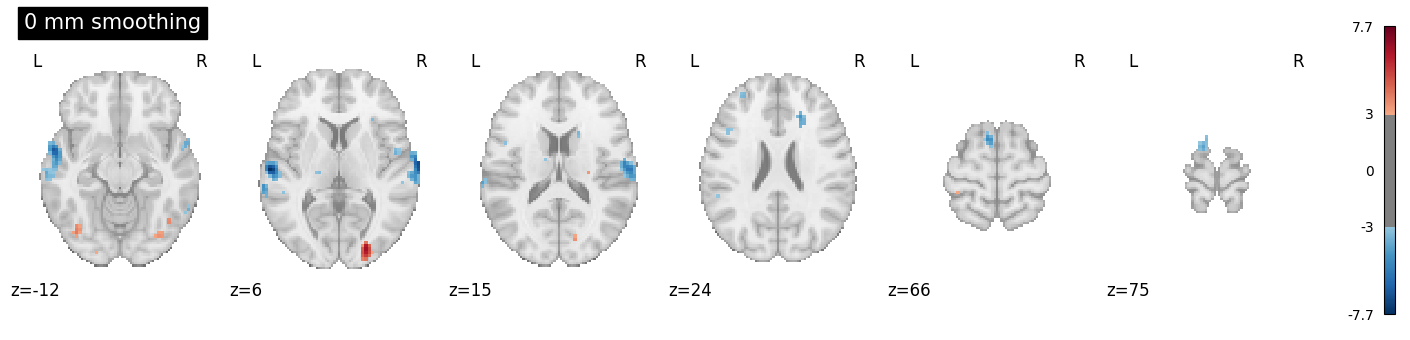

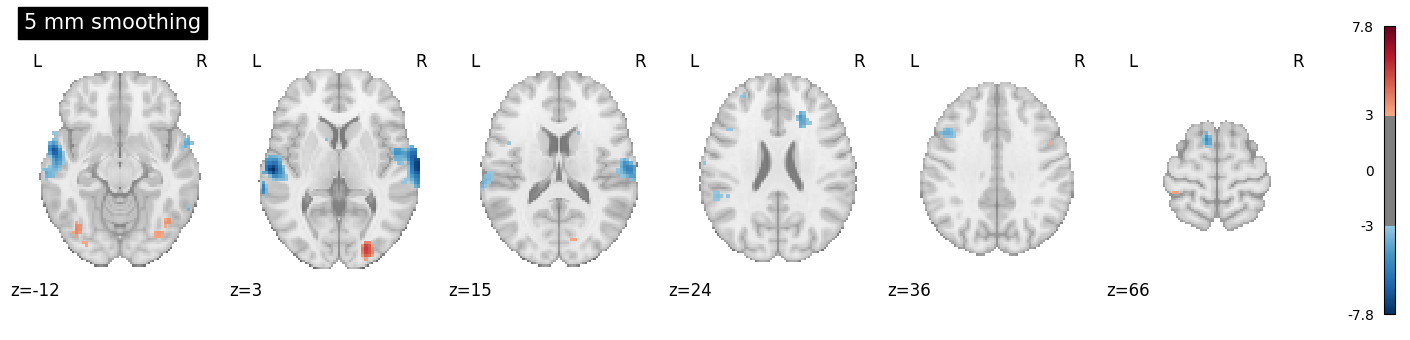

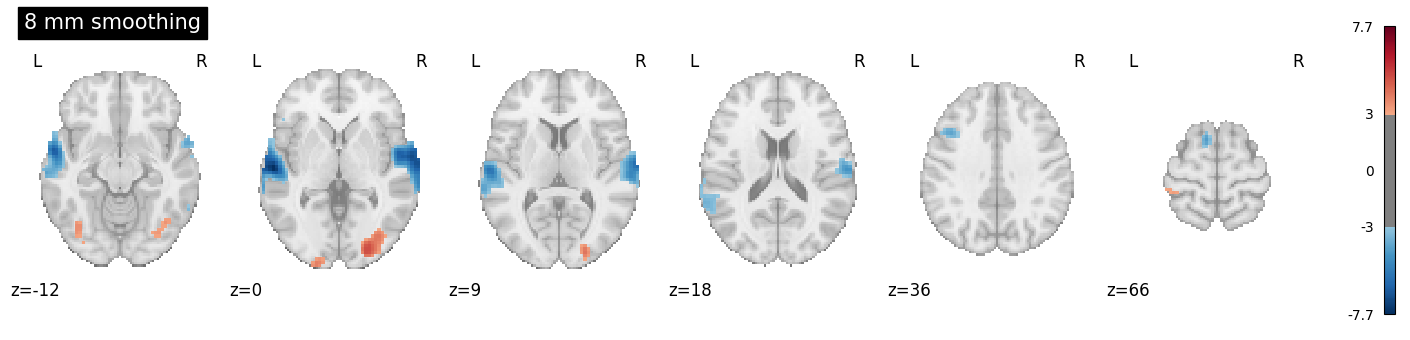

In [7]:
plotting.plot_stat_map(
    z0,
    threshold=3.0,
    display_mode="z",
    cut_coords=6,
    title="0 mm smoothing"
)

plotting.plot_stat_map(
    z5,
    threshold=3.0,
    display_mode="z",
    cut_coords=6,
    title="5 mm smoothing"
)

plotting.plot_stat_map(
    z8,
    threshold=3.0,
    display_mode="z",
    cut_coords=6,
    title="8 mm smoothing"
)

plotting.show()

In [8]:
import numpy as np

for name, zmap in zip(
    ["0 mm", "5 mm", "8 mm"],
    [z0, z5, z8]
):
    data = zmap.get_fdata()
    print(name, "max z =", np.nanmax(data))

0 mm max z = 6.4401200914491605
5 mm max z = 5.976695744807879
8 mm max z = 5.246456676293196
